# Example 1: Classification task on Iris Dataset using an h_ANFIS model with Gradient-based optimization

In [1]:
from sklearn.datasets import load_iris

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    accuracy_score,
    classification_report
)

import torch
import torch.nn as nn
import torch.utils.data as data

import numpy as np
import random

import neuro_fuzzy_toolbox as nft

In [2]:
SEED = 0
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

## Data

In [3]:
iris = load_iris()
X, y = iris.data, iris.target

In [4]:
x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=SEED
)

x_train, x_val, y_train, y_val = train_test_split(
    x_train, y_train, test_size=0.2, stratify=y_train, random_state=SEED
)

In [5]:
scaler = MinMaxScaler(feature_range=(0, 1))

x_train = torch.tensor(scaler.fit_transform(x_train), dtype=torch.float32)
x_val = torch.tensor(scaler.transform(x_val), dtype=torch.float32)
x_test = torch.tensor(scaler.transform(x_test), dtype=torch.float32)

y_train = torch.tensor(y_train)
y_val = torch.tensor(y_val)
y_test = torch.tensor(y_test)

## DataLoaders

In [6]:
generator = torch.Generator()
generator.manual_seed(SEED)

train_loader = data.DataLoader(data.TensorDataset(x_train, y_train), batch_size=8, shuffle=True, generator=generator)

val_loader = data.DataLoader(data.TensorDataset(x_val, y_val), batch_size=8, shuffle=False)

## Model

In [7]:
# Define model
model = nft.h_ANFIS(
    input_size=4,
    num_mfs=3,
    outputs=3,
    output_type="softmax",
    features=["sepal length", "sepal width", "petal length", "petal width"]
)

In [8]:
model.init_premises(x_train)
model.init_consequents(x_train, y_train, ridge_lambda=0.1)

## Learning Algorithm

In [9]:
# Define training strategy
trainer = nft.Basic_optimizer_training_algorithm(
    epochs=500,
    loss_function=nn.CrossEntropyLoss(),
    optimizer=torch.optim.AdamW,
    optimizer_params={'lr': 1e-3, 'weight_decay': 1e-2},
    early_stopping=nft.EarlyStopping(patience=30, delta=1e-4)
)

In [10]:
# Train model
trainer(model, train_loader, val_loader)

/home/jsuarez/workspaces/neuro-fuzzy-toolbox/env/lib/python3.12/site-packages/torch/autograd/graph.py:869: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12080). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch:   1/500 - loss: 0.576028 - validation loss: 0.622348
Epoch:   2/500 - loss: 0.556858 - validation loss: 0.604620
Epoch:   3/500 - loss: 0.538645 - validation loss: 0.588852
Epoch:   4/500 - loss: 0.521300 - validation loss: 0.571750
Epoch:   5/500 - loss: 0.504510 - validation loss: 0.555888
Epoch:   6/500 - loss: 0.488991 - validation loss: 0.542411
Epoch:   7/500 - loss: 0.474197 - validation loss: 0.523635
Epoch:   8/500 - loss: 0.459703 - validation loss: 0.509008
Epoch:   9/500 - loss: 0.445952 - validation loss: 0.497380
Epoch:  10/500 - loss: 0.432324 - validation loss: 0.481987
Epoch:  11/500 - loss: 0.419115 - validation loss: 0.469565
Epoch:  12/500 - loss: 0.406454 - validation loss: 0.459826
Epoch:  13/500 - loss: 0.394148 - validation loss: 0.448445
Epoch:  14/500 - loss: 0.382328 - validation loss: 0.441761
Epoch:  15/500 - loss: 0.371072 - validation loss: 0.432061
Epoch:  16/500 - loss: 0.360248 - validation loss: 0.423937
Epoch:  17/500 - loss: 0.349878 - valida

## Evaluation

In [11]:
pred = model.predict(x_test)

acc = accuracy_score(y_test, pred)
prec = precision_score(y_test, pred, average='weighted', zero_division=0)
recall = recall_score(y_test, pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, pred, average='weighted', zero_division=0)
conf_matrix = confusion_matrix(y_test, pred)
class_rep = classification_report(y_test, pred)

print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", recall)
print("f1 score:", f1, "\n")

print("Confusion Matrix:")
print(conf_matrix, "\n")

print("Classification Report:")
print(class_rep)

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
f1 score: 1.0 

Confusion Matrix:
[[15  0  0]
 [ 0 15  0]
 [ 0  0 15]] 

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      1.00      1.00        15
           2       1.00      1.00      1.00        15

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



## Rule structure analysis

In [12]:
print(model.get_rules_structure().to_string())

            premises                                                                                                                      output 1 consequents                                                output 2 consequents                                                output 3 consequents                                               
        sepal length                     sepal width                     petal length                     petal width                             sepal length sepal width petal length petal width                   sepal length sepal width petal length petal width                   sepal length sepal width petal length petal width          
                   a         b         c           a         b         c            a         b         c           a         b         c                   c0          c1           c2          c3        c4                   c0          c1           c2          c3        c4                   c0          c1          

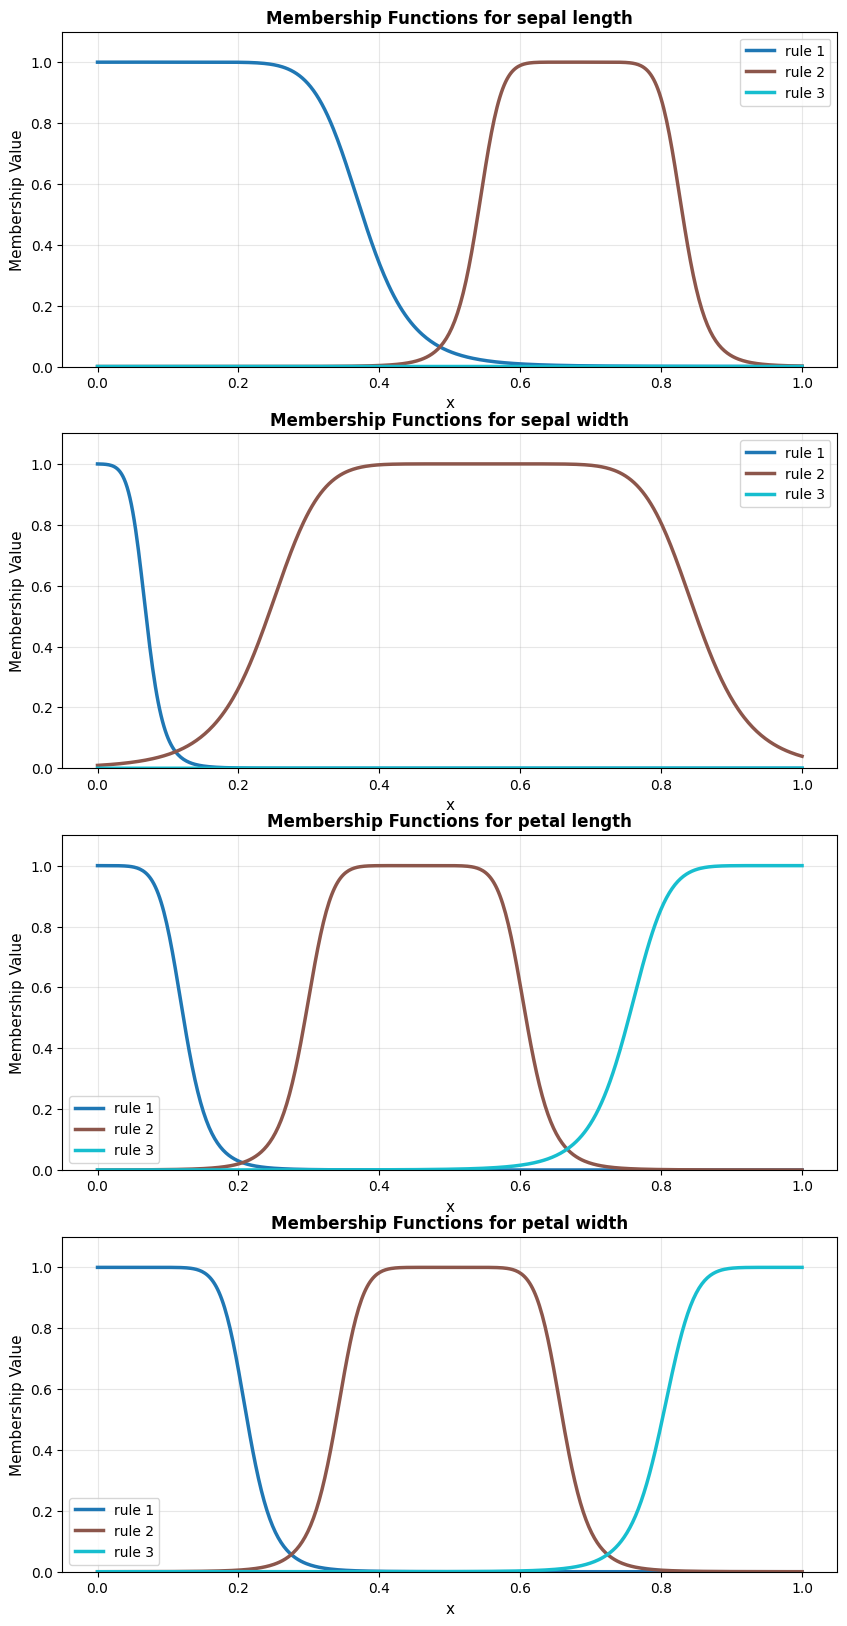

In [13]:
model.plot_premises(group_by_dim=True)

In [14]:
# Rule analysis for one sample
analyzer = nft.RulesAnalyzer(model)

top_rules = analyzer.top_activated_rules(x_test[0:1], top_k=3, sort_by="leave_one_rule_out")

In [15]:
for class_label in top_rules:
    print(f"{class_label}:")
    print(top_rules[class_label].to_string(), "\n")

class_0:
   rule_id  firing_level  rule_output  contribution  I_logit_margin_max  I_logit_margin_mean  I_prob
0       53  1.751464e-13    -0.144441 -2.529828e-14       -4.459777e-14        -2.978208e-14     0.0
1       62  2.913474e-21    -0.137805 -4.014923e-22       -1.052639e-21        -6.202652e-22     0.0
2       61  9.106845e-24    -0.114750 -1.045014e-24       -2.155477e-24        -1.098971e-24     0.0 

class_1:
   rule_id  firing_level  rule_output  contribution  I_logit_margin_max  I_logit_margin_mean        I_prob
0       15  8.753379e-05     0.658258  5.761984e-05            0.000027             0.000172  1.317821e-07
1       17  1.669576e-06     1.864878  3.113556e-06            0.000005             0.000007  2.235174e-08
2       41  2.438206e-07     2.951781  7.197052e-07            0.000001             0.000001  4.656613e-09 

class_2:
   rule_id  firing_level  rule_output  contribution  I_logit_margin_max  I_logit_margin_mean    I_prob
0       45      0.972177     3.168

In [19]:
explanation = analyzer.explain_prediction(x_test[0:1], top_k=3, sort_by="leave_one_rule_out")
print(explanation)

PREDICTION EXPLANATION

Predicted class: 2
Predicted probability: 0.9908

Logits and probabilities:
  Class 0: logit=-2.2506, p=0.0044
  Class 1: logit=-2.1909, p=0.0047
  Class 2: logit=3.1558, p=0.9908

Explaining predicted class: 2

Top rules (sorted by change in predicted class probability when the rule is removed):
----------------------------------------------------------------------

Rule 45 | w=0.9722 | f(x)=3.1681 | contrib=+3.0800 | I_prob=+0.6239
  IF sepal length ∈ [0.57, 0.80] AND sepal width ∈ [0.30, 0.79] AND petal length ∈ [0.80, 1.17] AND petal width ∈ [0.84, 1.16] THEN f_0(x) = -0.591*sepal length - 0.548*sepal width - 0.578*petal length - 0.561*petal width - 0.577 
                                                                                                                                    f_1(x) = -0.596*sepal length - 0.541*sepal width - 0.585*petal length - 0.533*petal width - 0.553 
                                                                            